<a href="https://colab.research.google.com/github/yadavrishikesh/Deep-Learning-Slides-Code/blob/main/code/CNN/CNNs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Convolutional Neural Networks (CNN) using TensorFlow

In this notebook we will learn:

- What is CNN
- Load image dataset
- Build CNN model
- Train model
- Test accuracy
- Make predictions

We will use MNIST handwritten digits dataset.

Images look like:

- 0,1,2,3,4,5,6,7,8,9
- size = 28 × 28
- grayscale images

In [2]:
# TensorFlow main library
import tensorflow as tf

# Keras high-level API inside TensorFlow
from tensorflow import keras

# Layers used to build CNN
from tensorflow.keras import layers

# plotting
import matplotlib.pyplot as plt

# numerical computation
import numpy as np

## Load Public Dataset (MNIST)

In [3]:
# Load dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Print shapes
print("Training images shape:", x_train.shape)
print("Training labels shape:", y_train.shape)

print("Test images shape:", x_test.shape)
print("Test labels shape:", y_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training images shape: (60000, 28, 28)
Training labels shape: (60000,)
Test images shape: (10000, 28, 28)
Test labels shape: (10000,)


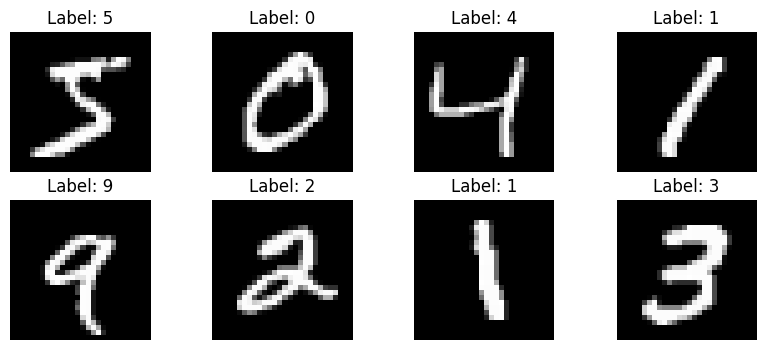

In [4]:
plt.figure(figsize=(10,4))

for i in range(8):
    plt.subplot(2,4,i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title("Label: " + str(y_train[i]))
    plt.axis('off')

plt.show()

# Step 1 — Normalize Data

Pixel values range from 0–255. We need to scale them to 0–1. This improves training and avoild any issues of .

In [5]:
x_train = x_train / 255.0
x_test  = x_test  / 255.0

## Step 2 — Add Channel Dimension

CNN expects: (batch, height, width, channels), but currently
(60000, 28, 28)

In [6]:
x_train = x_train[..., None]
x_test  = x_test[..., None]

print(x_train.shape)

(60000, 28, 28, 1)


# Step 3 — Build CNN Model

This is the most important part. We build layers one by one.

In [7]:
model = keras.Sequential([

    # First convolution layer
    # 16 filters, kernel size 3x3
    # ReLU activation
    layers.Conv2D(
        filters=16,
        kernel_size=3,
        activation='relu',
        input_shape=(28,28,1)
    ),

    # Reduce image size
    layers.MaxPooling2D(pool_size=2),

    # Second convolution layer
    layers.Conv2D(
        filters=32,
        kernel_size=3,
        activation='relu'
    ),

    # pooling again
    layers.MaxPooling2D(pool_size=2),

    # flatten to vector
    layers.Flatten(),

    # fully connected layer
    layers.Dense(128, activation='relu'),

    # output layer (10 digits)
    layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# Step 4 — Model Summary

This shows architecture. We may observe:

- Conv layers
- pooling layers
- dense layers
- parameters

In [8]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 800)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       102,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 108,618 (424.29 KB)

 Trainable params: 108,618 (424.29 KB)

 Non-trainable params: 0 (0.00 B)

## Step 5 — Compile Model

We define:

- optimizer
- loss
- metrics

In [9]:
model.compile(

    # optimizer updates weights
    optimizer='adam',

    # classification loss
    loss='sparse_categorical_crossentropy',

    # track accuracy
    metrics=['accuracy']
)

# Step 6 — Train Model
 You may see:

- loss decreasing
- accuracy increasing

In [10]:
history = model.fit(

    # training data
    x_train,
    y_train,

    # number of passes
    epochs=5,

    # validation split
    validation_split=0.1
)

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 38s 21ms/step - accuracy: 0.9503 - loss: 0.1654 - val_accuracy: 0.9847 - val_loss: 0.0566
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 32s 19ms/step - accuracy: 0.9833 - loss: 0.0535 - val_accuracy: 0.9847 - val_loss: 0.0504
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 34s 20ms/step - accuracy: 0.9884 - loss: 0.0371 - val_accuracy: 0.9870 - val_loss: 0.0396
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 32s 19ms/step - accuracy: 0.9908 - loss: 0.0274 - val_accuracy: 0.9890 - val_loss: 0.0403
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 39s 23ms/step - accuracy: 0.9926 - loss: 0.0223 - val_accuracy: 0.9893 - val_loss: 0.0385


# Step 7 — Evaluate Model

Test accuracy on unseen data.

In [11]:
test_loss, test_acc = model.evaluate(
    x_test,
    y_test
)

print("Test accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9875 - loss: 0.0374
Test accuracy: 0.987500011920929


# Step 8 — Make Predictions

In [12]:
predictions = model.predict(x_test)
np.argmax(predictions[0])

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


np.int64(7)

# Step 9 — Show Predictions

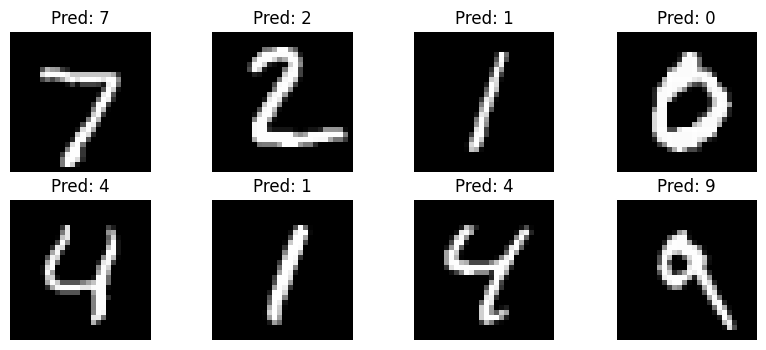

In [13]:
plt.figure(figsize=(10,4))

for i in range(8):

    plt.subplot(2,4,i+1)

    plt.imshow(x_test[i].squeeze(), cmap='gray')

    pred = np.argmax(predictions[i])

    plt.title("Pred: " + str(pred))

    plt.axis('off')

plt.show()